Ingrese el número de semanas (ej. 10): 4
Ingrese el número de simulaciones (ej. 5): 100

 Ojivas


<ipython-input-5-a8250e6c7320>:125: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


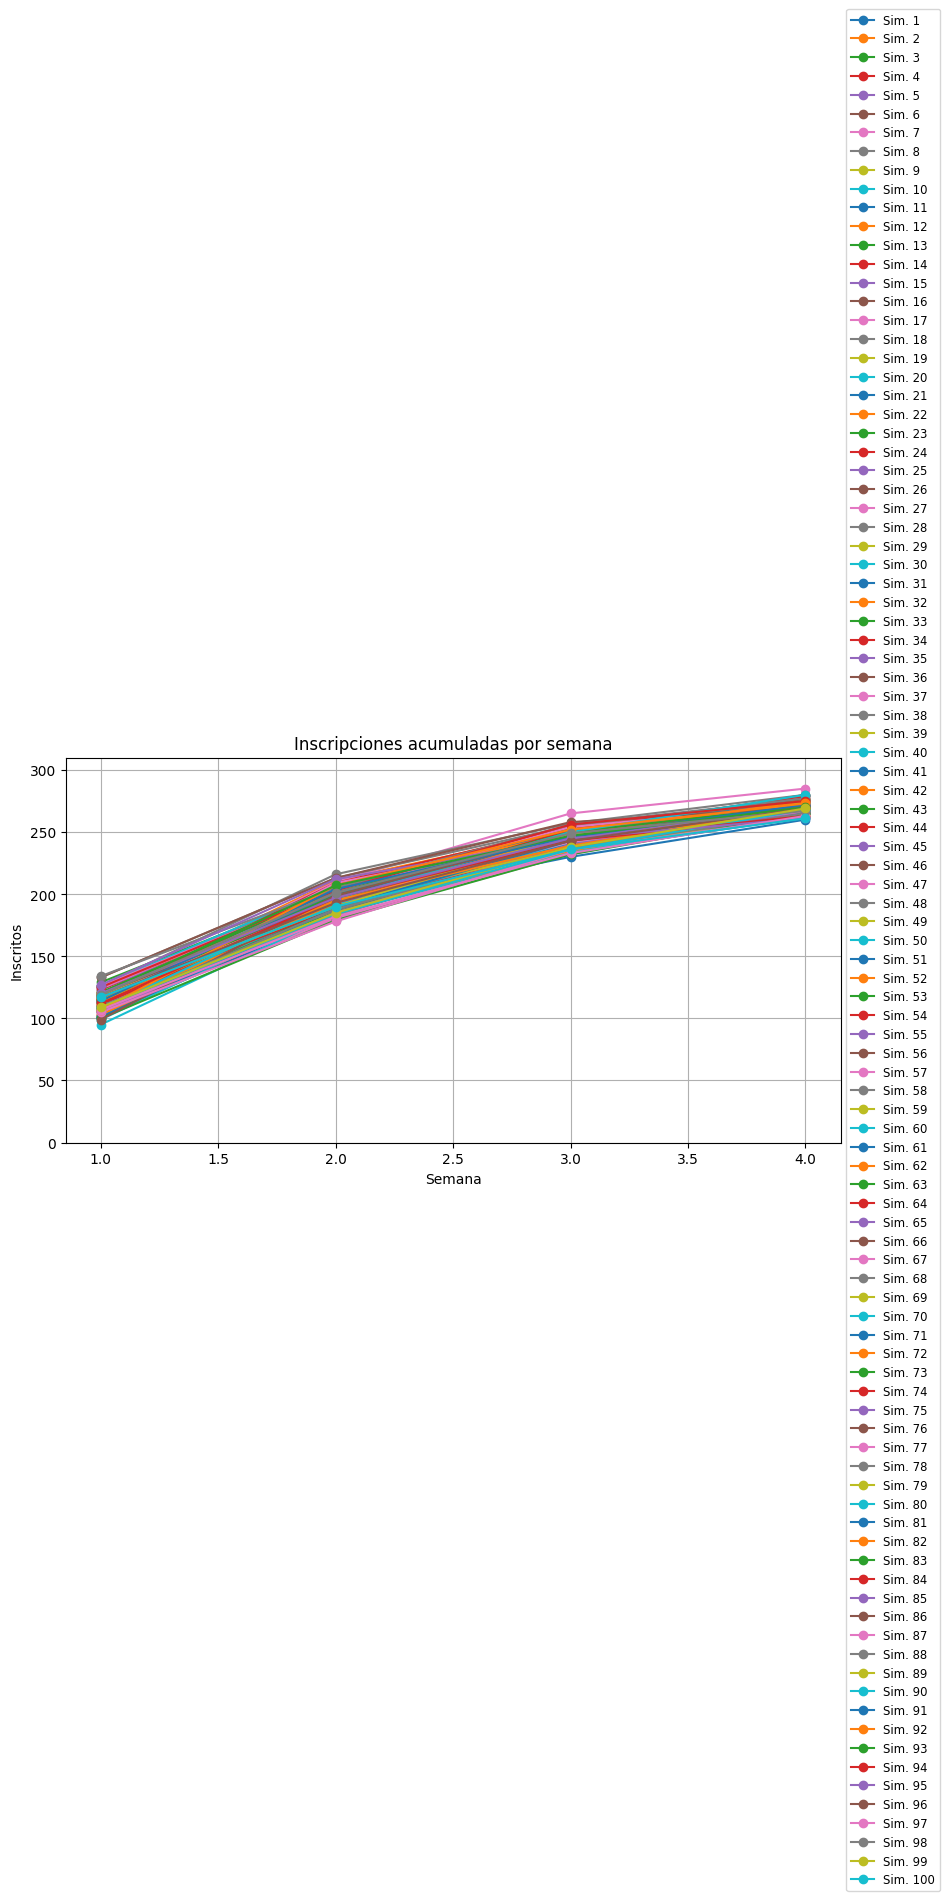

<ipython-input-5-a8250e6c7320>:136: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


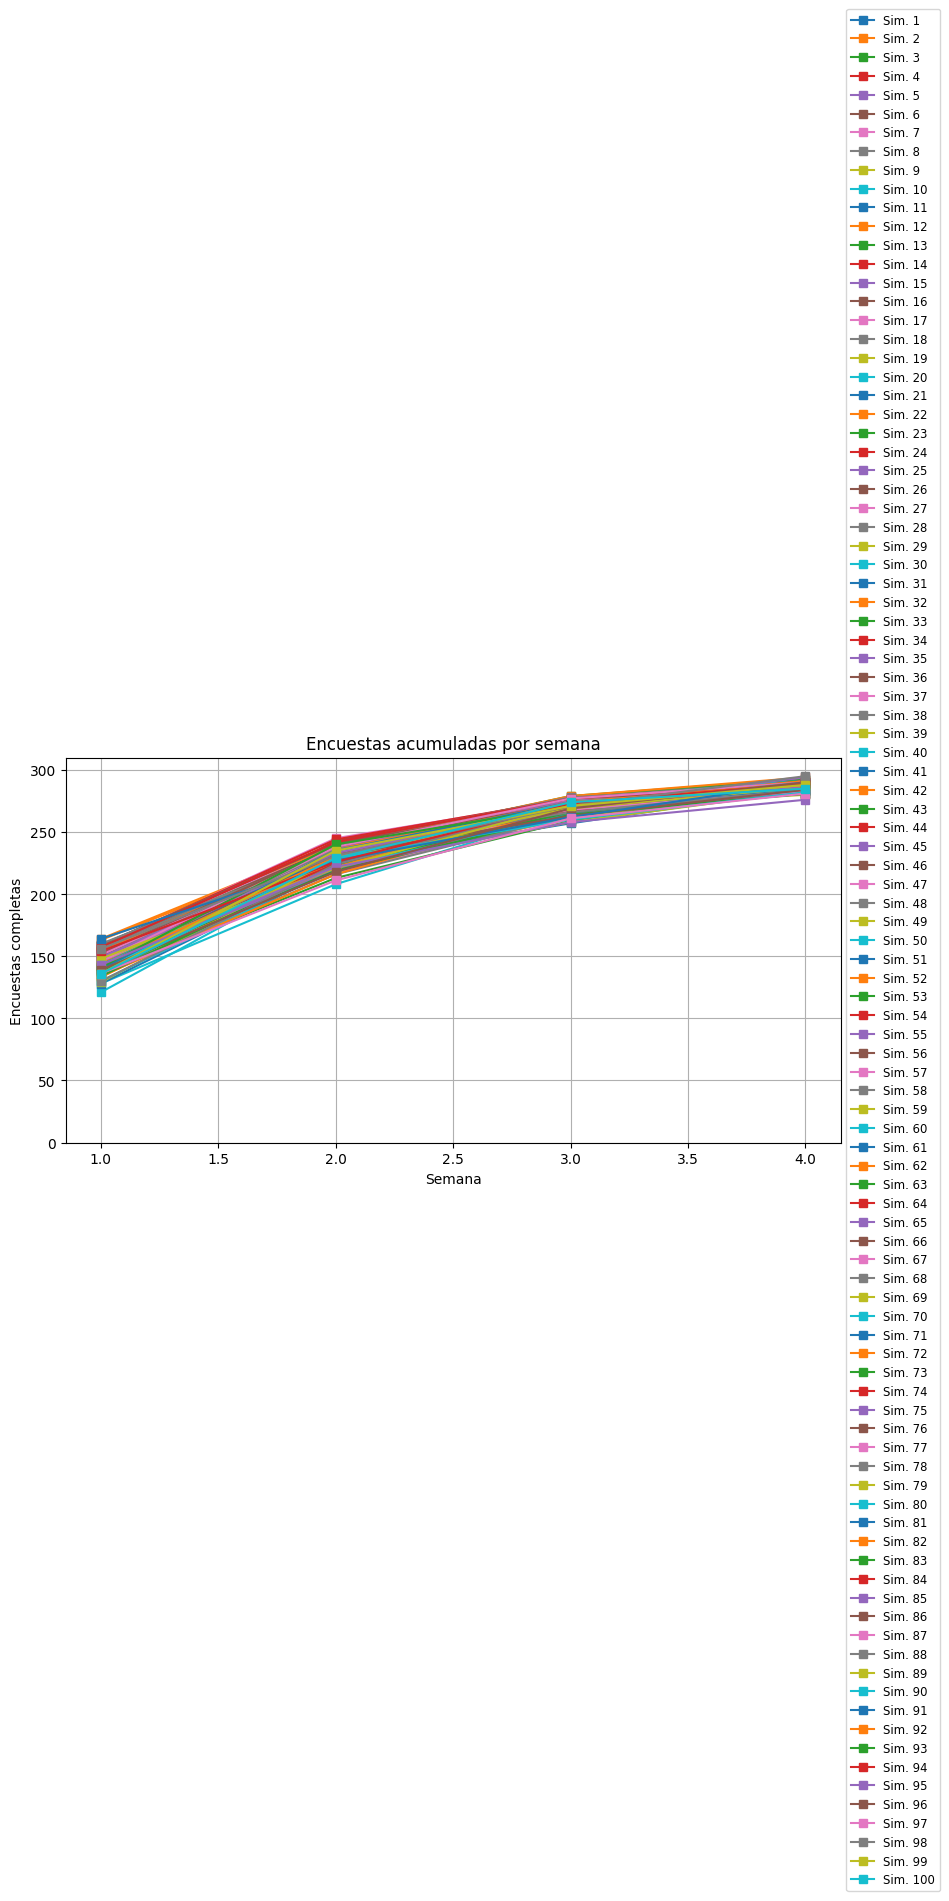


 Histograma inscritos


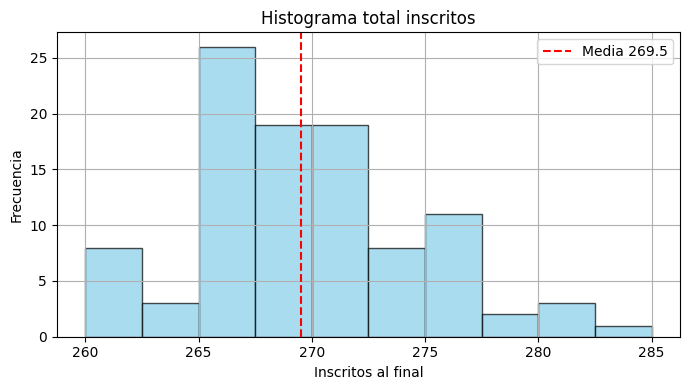


 Histograma encuestas


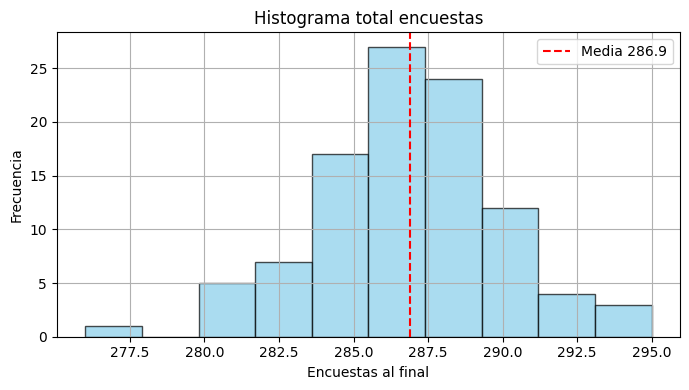


 Diagrama de dispersión


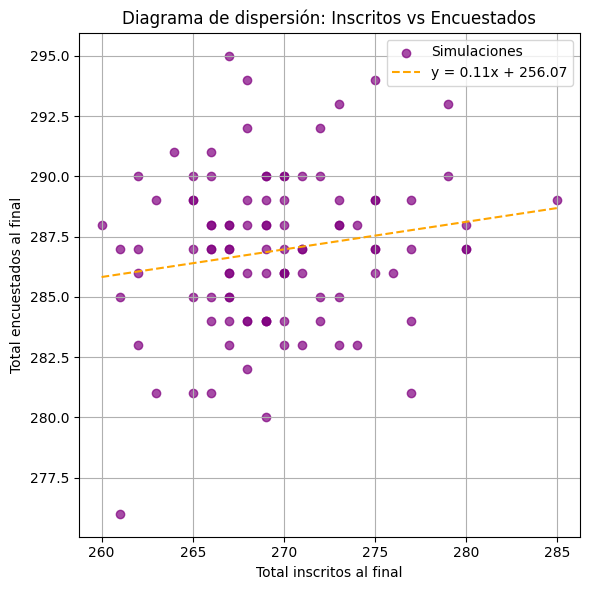


== RESULTADOS FINALES ==
Inscripciones - Media: 269.51, Desv. Est.: 4.82, Error % medio: 1.39%
Encuestas     - Media: 286.91, Desv. Est.: 3.20, Error % medio: 0.85%

📌 Última simulación:
- Inscritos totales:  261
- Encuestas totales:  285


In [5]:
import numpy as np               # Importa NumPy para manejo eficiente de arreglos y funciones numéricas
import matplotlib.pyplot as plt  # Importa Matplotlib para graficar los resultados

# ---------- PARÁMETROS GENERALES ----------
N_PERSONAS = 300                # Número total de personas simuladas
ESTADOS = ['E', 'Ne', 'N', 'Ni', 'I']  # Estados posibles de cada persona:
# E = Entusiasta, Ne = Neutro-Entusiasta, N = Neutro, Ni = Neutro-Indiferente, I = Indiferente

# Matriz de transición entre estados (sin estado de salida "OUT")
# Cada clave es un estado actual, y su valor es un diccionario con probabilidades de ir a otros estados
TRANSICION = {
    'E':  {'Ne': 0.541, 'N': 0.037, 'Ni': 0.129, 'I': 0.29},
    'Ne': {'E': 0.066, 'N': 0.058, 'Ni': 0.219, 'I': 0.569},
    'N':  {'E': 0.065, 'Ne': 0.01, 'Ni': 0.389, 'I': 0.167},
    'Ni': {'E': 0.407, 'Ne': 0.065, 'N': 0.065, 'I': 0.263},
    'I':  {'E': 0.077, 'Ne': 0.05, 'N': 0.05, 'Ni': 0.632}
}

# Probabilidades de inscripción y de completar encuesta según el estado actual
# Cada tupla es (prob_inscripción, prob_encuesta)
PROB_X_ESTADO = {
    'E':  (0.92, 0.96),
    'Ne': (0.65, 0.75),
    'N':  (0.45, 0.55),
    'Ni': (0.30, 0.45),
    'I':  (0.05, 0.15)
}

# ---------- FUNCIÓN DE TRANSICIÓN DE ESTADOS ----------
def transicionar_estados(estados_actuales):
    """
    Dada una lista/array de estados actuales, calcula el siguiente estado para cada persona
    usando las probabilidades de transición definidas en TRANSICION.
    """
    nuevos_estados = []
    for estado in estados_actuales:
        # Obtiene las posibles transiciones y sus probabilidades para el estado actual
        transiciones = list(TRANSICION[estado].items())
        destinos, probs = zip(*transiciones)  # Separar estados destino y probabilidades
        probs = np.array(probs)
        probs = probs / probs.sum()  # Normaliza para que sumen 1 (por si acaso no suman exacto)

        # Elige aleatoriamente el nuevo estado basado en las probabilidades
        nuevo = np.random.choice(destinos, p=probs)
        nuevos_estados.append(nuevo)
    return np.array(nuevos_estados)

# ---------- SIMULACIÓN PRINCIPAL ----------
def simulacion(n_semanas: int):
    """
    Ejecuta la simulación para un número dado de semanas.
    Para cada semana:
    - Actualiza el estado de cada persona según la matriz de transición.
    - Calcula quién se inscribe y quién completa la encuesta según probabilidades.
    - Acumula los totales de inscritos y encuestados.
    """
    # Inicializa los estados de las personas al azar (uniformemente entre los estados)
    estados = np.random.choice(ESTADOS, size=N_PERSONAS)
    # Arreglos booleanos que indican si la persona ya se inscribió o completó encuesta
    inscrito = np.zeros(N_PERSONAS, dtype=bool)
    encuestado = np.zeros(N_PERSONAS, dtype=bool)

    acumulado_insc = []  # Guarda total acumulado inscritos por semana
    acumulado_enc = []   # Guarda total acumulado encuestados por semana

    for _ in range(n_semanas):
        # Actualiza estados según matriz de transición
        estados = transicionar_estados(estados)

        # Para los que aún no se han inscrito, probabilidades de inscribirse según estado actual
        pendientes_insc = ~inscrito  # Negación: personas no inscritas
        if pendientes_insc.any():  # Si hay alguien pendiente
            probs_insc = np.array([PROB_X_ESTADO[e][0] for e in estados])
            rand_vals = np.random.random(N_PERSONAS)  # números aleatorios [0,1)
            # Se inscriben quienes no están inscritos y el número aleatorio es menor que su prob
            nuevos = pendientes_insc & (rand_vals < probs_insc)
            inscrito[nuevos] = True

        # Igual para encuesta: los que no han completado encuesta
        pendientes_enc = ~encuestado
        if pendientes_enc.any():
            probs_enc = np.array([PROB_X_ESTADO[e][1] for e in estados])
            rand_vals = np.random.random(N_PERSONAS)
            nuevos = pendientes_enc & (rand_vals < probs_enc)
            encuestado[nuevos] = True

        # Guarda totales acumulados para la semana actual
        acumulado_insc.append(int(inscrito.sum()))
        acumulado_enc.append(int(encuestado.sum()))

        # Si todos ya están inscritos y encuestados, termina anticipadamente la simulación
        if inscrito.all() and encuestado.all():
            faltan = n_semanas - len(acumulado_insc)
            # Completa con el total máximo para las semanas restantes
            acumulado_insc.extend([N_PERSONAS]*faltan)
            acumulado_enc.extend([N_PERSONAS]*faltan)
            break

    return acumulado_insc, acumulado_enc

# Ejecuta múltiples simulaciones para obtener resultados variados
def ejecutar_simulaciones(n_semanas: int, n_sim: int):
    resultados = []
    for _ in range(n_sim):
        insc, enc = simulacion(n_semanas)
        resultados.append({'inscritos': insc, 'encuestas': enc})
    return resultados

# ---------- FUNCIONES DE VISUALIZACIÓN ----------

def graficar_ojivas(resultados, n_semanas):
    """
    Grafica las curvas acumuladas (ojivas) de inscritos y encuestados por semana para cada simulación.
    """
    semanas = np.arange(1, n_semanas+1)

    plt.figure(figsize=(10,5))
    for i, r in enumerate(resultados, 1):
        plt.plot(semanas, r['inscritos'], marker='o', linewidth=1.5, label=f"Sim. {i}")
    plt.title("Inscripciones acumuladas por semana")
    plt.xlabel("Semana"); plt.ylabel("Inscritos")
    plt.ylim(0, N_PERSONAS+10)
    plt.grid(True)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1, fontsize='small')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10,5))
    for i, r in enumerate(resultados, 1):
        plt.plot(semanas, r['encuestas'], marker='s', linewidth=1.5, label=f"Sim. {i}")
    plt.title("Encuestas acumuladas por semana")
    plt.xlabel("Semana"); plt.ylabel("Encuestas completas")
    plt.ylim(0, N_PERSONAS+10)
    plt.grid(True)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1, fontsize='small')
    plt.tight_layout()
    plt.show()

def histograma_final(resultados, clave='inscritos'):
    """
    Dibuja un histograma con la distribución del total final (última semana) de inscritos o encuestas.
    Además, muestra la media en el gráfico.
    """
    finales = [r[clave][-1] for r in resultados]  # Extrae el último valor acumulado de cada simulación
    plt.figure(figsize=(7,4))
    plt.hist(finales, bins=10, edgecolor='black', alpha=0.7, color='skyblue')
    plt.axvline(np.mean(finales), color='red', ls='--', label=f"Media {np.mean(finales):.1f}")
    plt.title(f"Histograma total {clave}")
    plt.xlabel(f"{clave.capitalize()} al final")
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return np.array(finales)  # Devuelve los valores finales para análisis posterior

def graficar_dispersion(inscritos_finales, encuestas_finales):
    """
    Grafica un diagrama de dispersión que relaciona inscritos y encuestados al final de las simulaciones.
    Ajusta y muestra una línea de regresión lineal simple.
    """
    plt.figure(figsize=(6,6))
    plt.scatter(inscritos_finales, encuestas_finales, color='purple', alpha=0.7, label="Simulaciones")
    m, b = np.polyfit(inscritos_finales, encuestas_finales, 1)  # Ajuste lineal
    x_vals = np.array([min(inscritos_finales), max(inscritos_finales)])
    y_vals = m * x_vals + b
    plt.plot(x_vals, y_vals, color='orange', linestyle='--', label=f"y = {m:.2f}x + {b:.2f}")
    plt.title("Diagrama de dispersión: Inscritos vs Encuestados")
    plt.xlabel("Total inscritos al final")
    plt.ylabel("Total encuestados al final")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def metricas(finales):
    """
    Calcula estadísticas básicas de un arreglo de valores:
    - Media
    - Desviación estándar (poblacional)
    - Error porcentual medio relativo a la media
    """
    media = finales.mean()
    std   = finales.std(ddof=0)
    err   = np.abs((finales - media)/media)*100
    return media, std, err.mean()

# ---------- EJECUCIÓN MANUAL ----------
n_semanas = int(input("Ingrese el número de semanas (ej. 10): "))
n_simulaciones = int(input("Ingrese el número de simulaciones (ej. 5): "))

# Corre las simulaciones con los parámetros dados
resultados = ejecutar_simulaciones(n_semanas, n_simulaciones)

print("\n Ojivas")
graficar_ojivas(resultados, n_semanas)

print("\n Histograma inscritos")
finales_insc = histograma_final(resultados, 'inscritos')

print("\n Histograma encuestas")
finales_enc  = histograma_final(resultados, 'encuestas')

print("\n Diagrama de dispersión")
graficar_dispersion(finales_insc, finales_enc)

# Calcula y muestra métricas estadísticas
m_i, s_i, e_i = metricas(finales_insc)
m_e, s_e, e_e = metricas(finales_enc)

print("\n== RESULTADOS FINALES ==")
print(f"Inscripciones - Media: {m_i:.2f}, Desv. Est.: {s_i:.2f}, Error % medio: {e_i:.2f}%")
print(f"Encuestas     - Media: {m_e:.2f}, Desv. Est.: {s_e:.2f}, Error % medio: {e_e:.2f}%")

# Muestra los resultados de la última simulación para referencia
ult = resultados[-1]
print("\n📌 Última simulación:")
print(f"- Inscritos totales:  {ult['inscritos'][-1]}")
print(f"- Encuestas totales:  {ult['encuestas'][-1]}")
